<a href="https://colab.research.google.com/github/amazzoli/ComponentSystemsData/blob/main/datasets/legos/inspect_components.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cloning the repository in the colab folder structure
%%bash
git clone https://github.com/amazzoli/ComponentSystemsData.git

Cloning into 'ComponentSystemsData'...


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os, sys

# Changing directory where the notebook is placed
os.chdir('/content/ComponentSystemsData/datasets/legos')

sys.path.append('/content/ComponentSystemsData/py_utils/')
import plot_utils as pu

# Inspecting lego components: **colored bricks**

The table `components.tsv` contains information about lego bricks:

- **sparse_id**: identifier of the matrix coordinates in the sparse representation.
- **name**: extended name in the database https://rebrickable.com/.
- **part_id**: identifier of the shape in the dataset.
- **color_id**: identifier of the color in the dataset.
- **color**: extended color name.
- **category**: brick category.
- **material**: brick material.
- **abundance**: number of brick istances appearing in the all the lego sets.
- **occurrence**: number of lego sets in which the brick is present.

In [3]:
components = pd.read_csv('data/components.tsv', sep='\t', index_col=0)
components

,name,part_id,color_id,color,category,material,abundance,occurrence
sparse_id,,,,,,,,
0,Sticker Sheet for Set 663-1,003381,9999,[No Color/Any Color],Stickers,Plastic,1,1
69418,Slope 30° 1 x 2 x 2/3 with White '04' print,85984pr0044,4,Red,Bricks Sloped,Plastic,1,1
69421,"Slope 30° 1 x 2 x 2/3 with Black/Red Stripe, A...",85984pr0047,72,Dark Bluish Gray,Bricks Sloped,Plastic,1,1
69424,Slope 30° 1 x 2 x 2/3 with Black/Gold Lamborgh...,85984pr0050,15,White,Bricks Sloped,Plastic,1,1
69430,Slope 30° 1 x 2 x 2/3 with White 'TAXI' print,85984pr9996,0,Black,Bricks Sloped,Plastic,1,1
...,...,...,...,...,...,...,...,...
21208,Plate 1 x 2,3023,0,Black,Plates,Plastic,16633,2643
62545,Technic Pin Long with Friction Ridges Lengthwi...,6558,1,Blue,Technic Pins,Plastic,16701,923
44849,Technic Axle Pin with Friction Ridges Lengthwise,43093,1,Blue,Technic Pins,Plastic,20739,2222


### Abundance statistics
Ranked abundances (Zipf's law) and abundance distribution

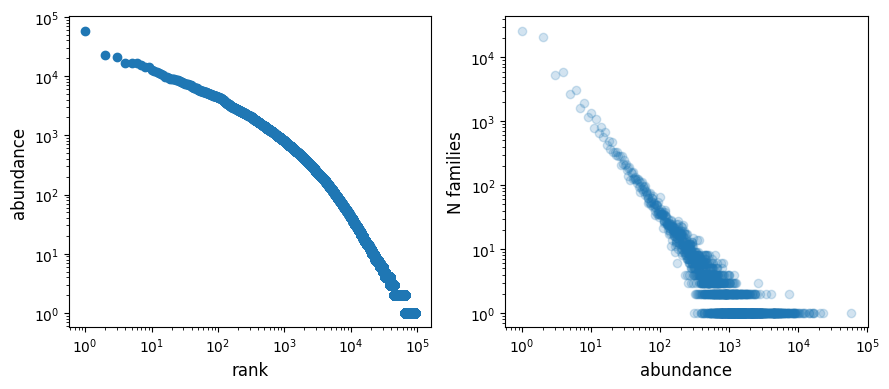

In [4]:
abundances = components.abundance.values

fig, (ax1, ax2) = plt.subplots(1,2,figsize=(9,4))

ax1 = pu.plot_count_rank(ax1, abundances, ylabel='abundance')

ax2 = pu.plot_count_hist_nobin(ax2, abundances, alpha=0.2, xlabel='abundance', ylabel='N families')

plt.tight_layout()

### Sharing statistics

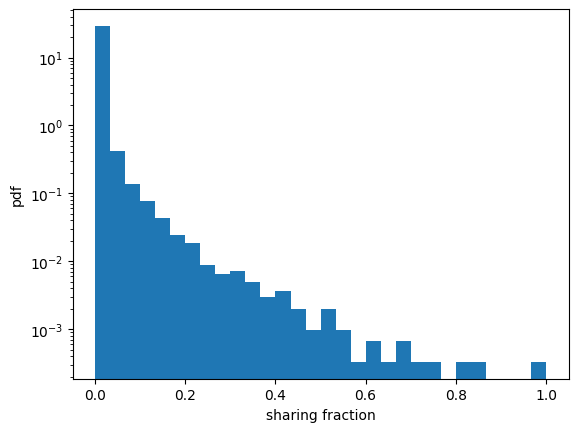

In [5]:
sharing_frac = components.occurrence / max(components.occurrence)

plt.yscale('log')
plt.xlabel('sharing fraction')
plt.ylabel('pdf')
h = plt.hist(sharing_frac, bins=30, density=True)

### LEGO bricks counts of categories

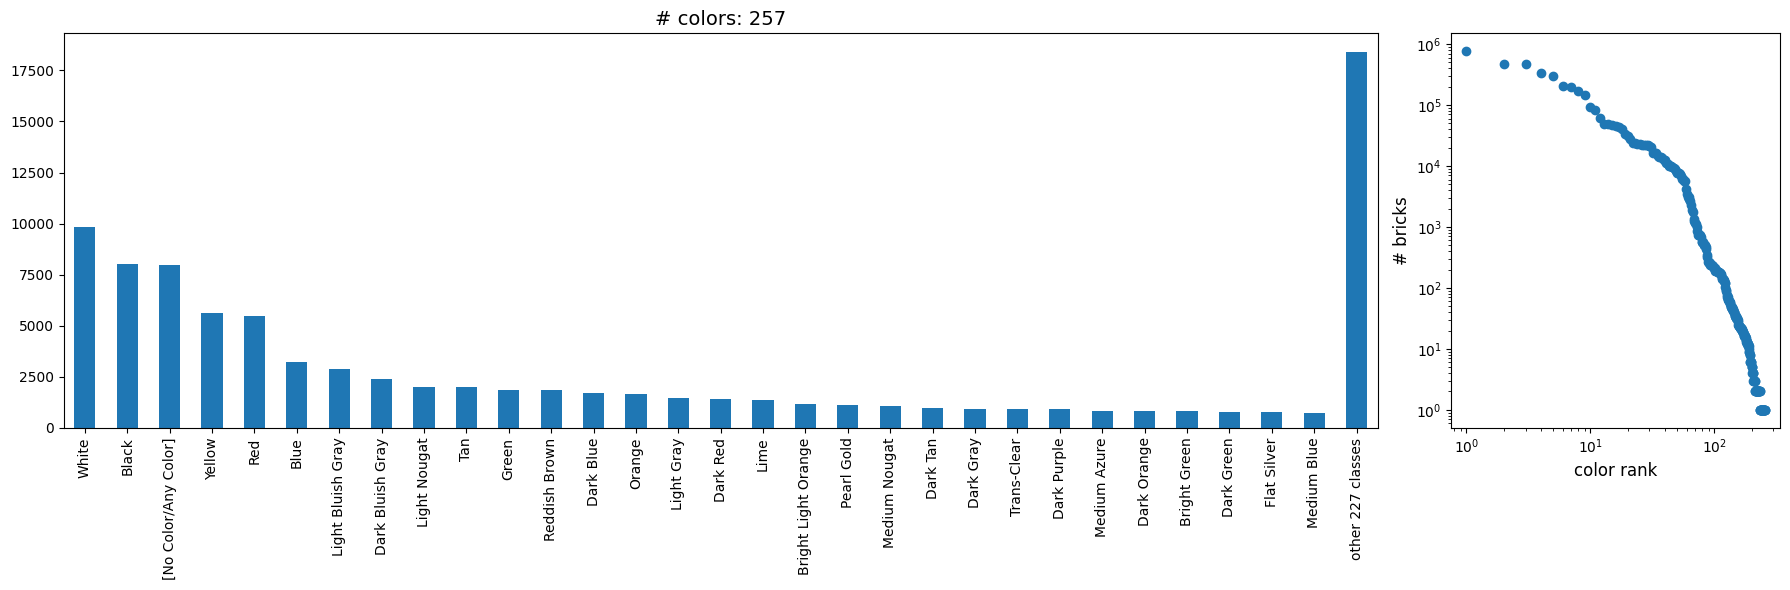

In [6]:
n_uniq_colors = components['color'].value_counts()
ab_colors = components.groupby('color').agg({'abundance':"sum"}).abundance

fig, (ax1, ax2) = plt.subplots(1,2,figsize=(18, 6), gridspec_kw={'width_ratios': [4, 1]})
ax1 = pu.plot_sorted_bar(ax1, n_uniq_colors, n_classes=30)
ax1.set_title('# colors: '+str(len(n_uniq_colors)), fontsize=14)
ax2 = pu.plot_count_rank(ax2, ab_colors.values, xlabel='color rank', ylabel='# bricks')
plt.tight_layout()

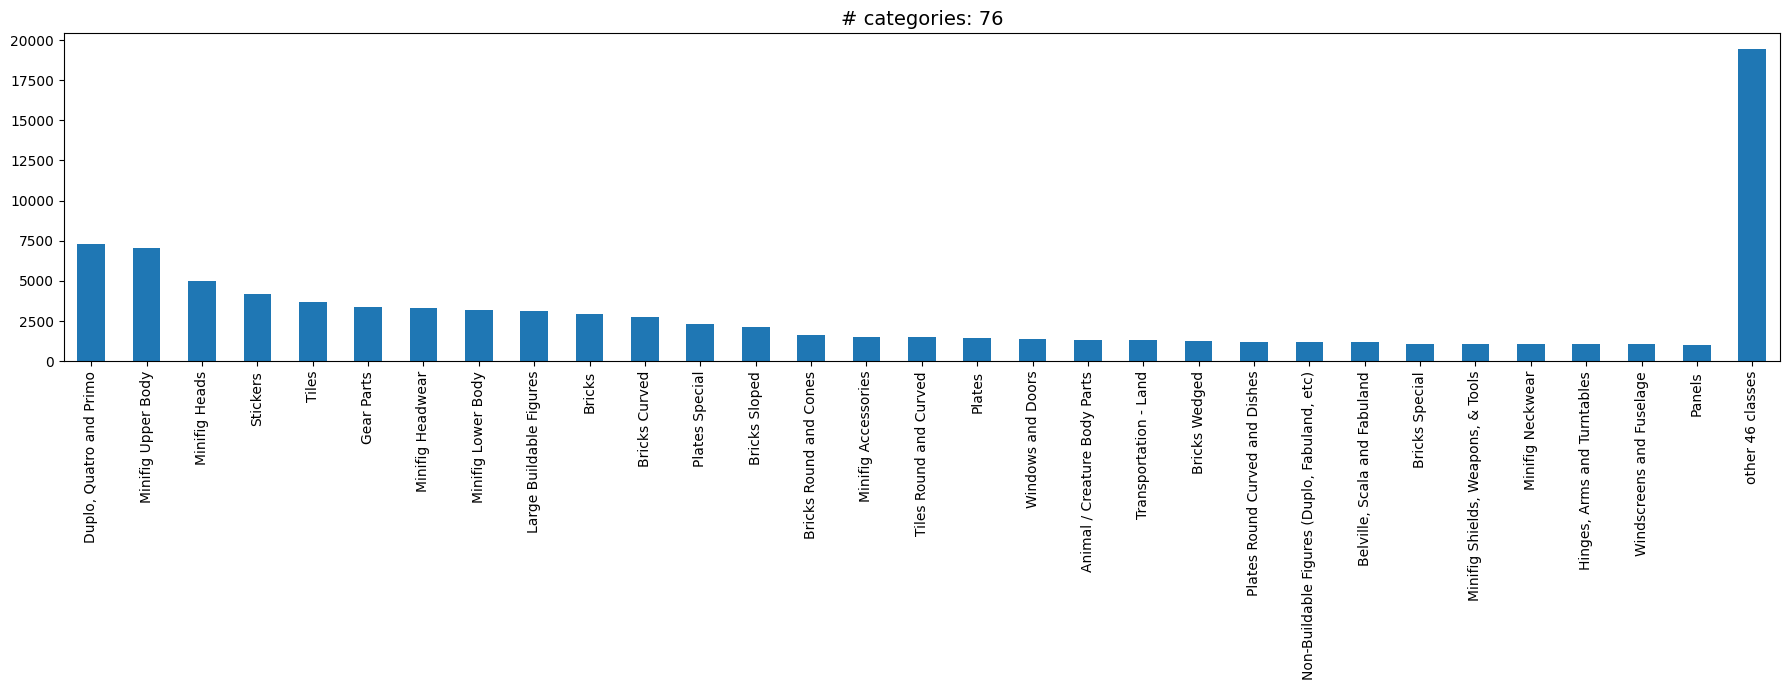

In [7]:
n_uniq_categs = components['category'].value_counts()

fig, ax1 = plt.subplots(1,1,figsize=(18, 7))
ax1.set_title('# categories: '+str(len(n_uniq_categs)), fontsize=14)
ax1 = pu.plot_sorted_bar(ax1, n_uniq_categs, n_classes=30)
plt.tight_layout()

## Generating an artificial sampled system

In [16]:
# Getting frequencies and sizes
freqs = (components['abundance'] / components['abundance'].sum()).values
objects = pd.read_csv('data/objects.tsv', sep='\t', index_col=0)
sizes = objects['size'].values

In [42]:
# Computing the sampling (30s)

import tqdm

progress = tqdm.tqdm(total=len(sizes))
sampl_matrix = np.zeros((len(freqs), len(sizes)))
for j in range(len(sizes)):
  sample = np.random.choice(len(freqs), p=freqs, size=sizes[j])
  ids, counts = np.unique(sample, return_counts=True)
  sampl_matrix[ids,j] = counts
  progress.update(1)

100%|█████████▉| 33518/33530 [00:31<00:00, 696.03it/s]

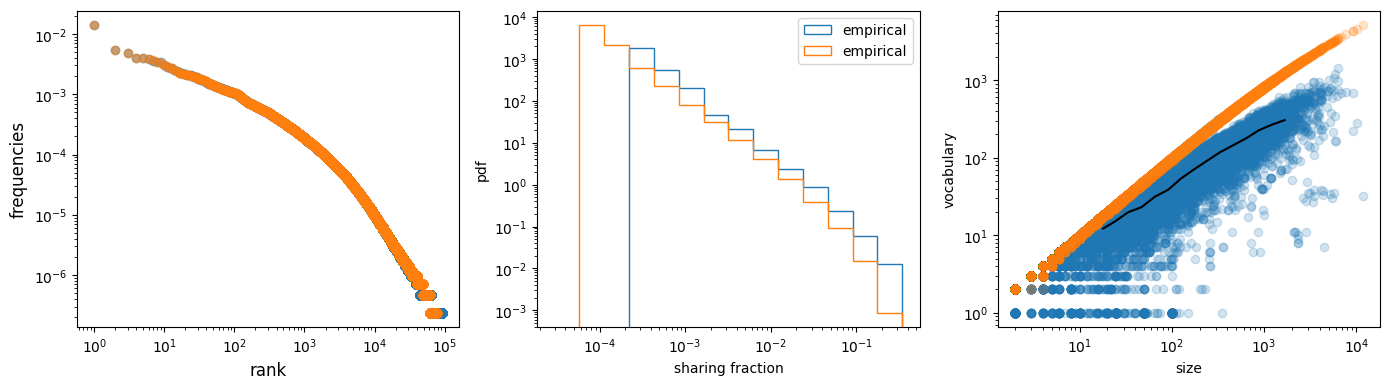

In [70]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3,figsize=(14, 4))

# Zipf law, sanity check that's the same of the empirical (on average)
freq_samp = sampl_matrix.sum(axis=1)
freq_samp /= freq_samp.sum()
sort_ids = np.argsort(freq_samp)[::-1]

ax1 = pu.plot_count_rank(ax1, freqs, ylabel='frequencies', alpha=0.5)
ax1 = pu.plot_count_rank(ax1, freq_samp, ylabel='frequencies', alpha=0.5)


# "U" law
sharing_samp = (sampl_matrix > 0).sum(axis=1).astype(float)
sharing_samp /= len(sizes)
sharing_samp = sharing_samp[sharing_samp > 0]

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('sharing fraction')
ax2.set_ylabel('pdf')
bins = np.logspace(np.log10(sharing_samp.min()), np.log10(sharing_samp.max()), 15)
ax2.hist(sharing_frac, bins=bins, density=True, histtype='step', label='empirical', lw=2)
ax2.hist(sharing_samp, bins=bins, density=True, histtype='step', label='empirical', lw=2)
ax2.legend()

# Heaps law
voc = objects['vocabulary'].values
voc_samp = (sampl_matrix > 0).sum(axis=0)
ax3.set_xscale('log')
ax3.set_yscale('log')
ax3.set_xlabel('size')
ax3.set_ylabel('vocabulary')

ax3.scatter(sizes, voc, alpha=0.2, label='empirical')
ax3.scatter(sizes, voc_samp, alpha=0.2, label='empirical')

plt.tight_layout()